# 01 — Exploratory Data Analysis: MovieLens
Understanding the interaction data that drives the two-stage recommender: sparsity, the positive-interaction threshold, per-user activity, the temporal structure that motivates our split, genres, and the popularity long tail (which is why we sample popularity-based hard negatives).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
PALETTE = ['#2a78d6','#eb6834','#1baf7a','#eda100','#e87ba4']
plt.rcParams.update({'axes.spines.top':False,'axes.spines.right':False,
                     'axes.grid':True,'grid.alpha':0.25,'axes.axisbelow':True})
DATA = Path('../data/ml-latest-small')
ratings = pd.read_csv(DATA/'ratings.csv'); movies = pd.read_csv(DATA/'movies.csv')
print('ratings:', ratings.shape, '| movies:', movies.shape)
ratings.head()

ratings: (100836, 4) | movies: (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## Scale & sparsity

In [2]:
n_users = ratings.userId.nunique(); n_items = ratings.movieId.nunique()
density = len(ratings)/(n_users*n_items)
print(f'users={n_users}  items={n_items}  interactions={len(ratings)}')
print(f'matrix density = {density:.4%}  (recsys matrices are extremely sparse)')

users=610  items=9724  interactions=100836
matrix density = 1.7000%  (recsys matrices are extremely sparse)


## Rating distribution and the positive threshold
We treat ratings >= 4.0 as positive engagement (implicit-feedback style).

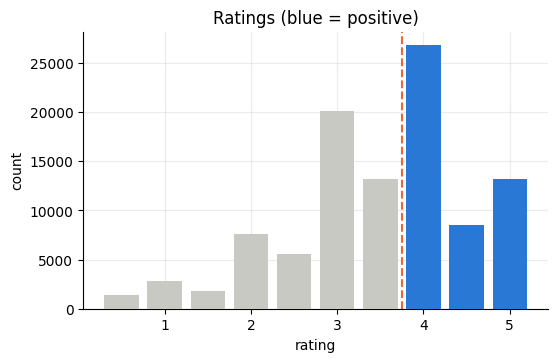

positive fraction (>= 4.0): 48.18%


In [3]:
thr = 4.0
fig, ax = plt.subplots(figsize=(6,3.6))
vc = ratings.rating.value_counts().sort_index()
colors = [PALETTE[0] if r>=thr else '#c9c9c4' for r in vc.index]
ax.bar(vc.index, vc.values, width=0.4, color=colors, zorder=3)
ax.axvline(thr-0.25, ls='--', color=PALETTE[1], lw=1.5)
ax.set_xlabel('rating'); ax.set_ylabel('count'); ax.set_title('Ratings (blue = positive)')
plt.show()
print(f'positive fraction (>= {thr}): {(ratings.rating>=thr).mean():.2%}')

## Interactions per user
The long left tail here is exactly the cold-start slice we break metrics out on.

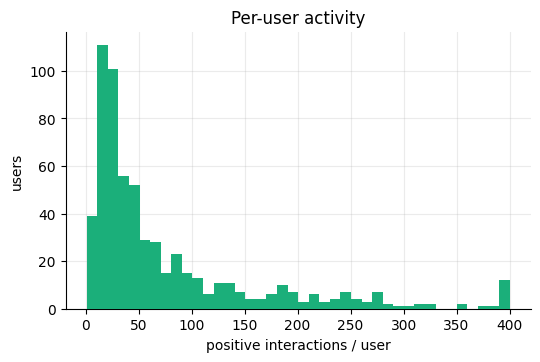

{'count': 609.0, 'mean': 79.8, 'std': 109.4, 'min': 1.0, '25%': 21.0, '50%': 40.0, '75%': 92.0, 'max': 1227.0}


In [4]:
pos = ratings[ratings.rating>=thr]
per_user = pos.groupby('userId').size()
fig, ax = plt.subplots(figsize=(6,3.6))
ax.hist(per_user.clip(upper=400), bins=40, color=PALETTE[2], zorder=3)
ax.set_xlabel('positive interactions / user'); ax.set_ylabel('users')
ax.set_title('Per-user activity'); plt.show()
print(per_user.describe().round(1).to_dict())

## Temporal structure — why we split by time, not randomly
Ratings span years; a random split would leak future interactions into the training past. We hold out each user's most recent interactions as test.

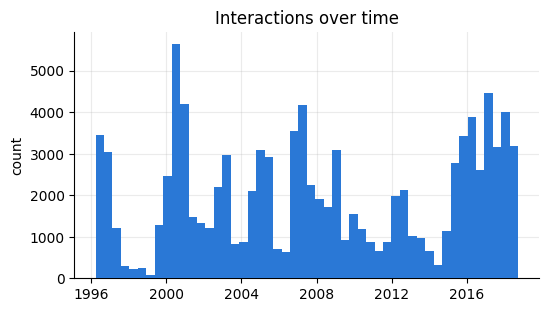

user 414: 1227 positives; last 2 timestamps held out as test:
[datetime.date(2018, 5, 5), datetime.date(2018, 6, 2)]


In [5]:
ts = pd.to_datetime(ratings.timestamp, unit='s')
fig, ax = plt.subplots(figsize=(6,3.2))
ax.hist(ts, bins=50, color=PALETTE[0], zorder=3)
ax.set_title('Interactions over time'); ax.set_ylabel('count'); plt.show()
# illustrate the per-user leave-last-out split on one user
u = per_user.idxmax(); uh = pos[pos.userId==u].sort_values('timestamp')
print(f'user {u}: {len(uh)} positives; last 2 timestamps held out as test:')
print(pd.to_datetime(uh.timestamp.tail(2), unit='s').dt.date.tolist())

## Genres and the popularity long tail

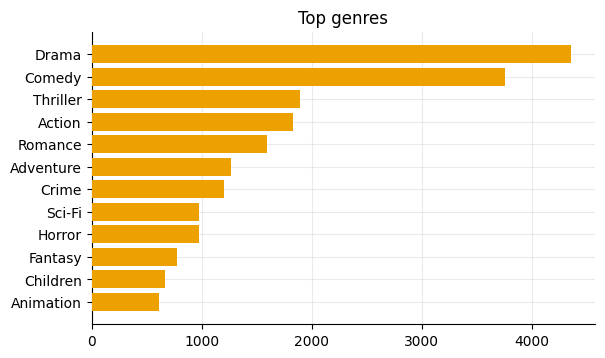

In [6]:
gen = movies.genres.str.get_dummies('|').sum().sort_values(ascending=False)
gen = gen.drop('(no genres listed)', errors='ignore').head(12)
fig, ax = plt.subplots(figsize=(6.5,3.8))
ax.barh(gen.index[::-1], gen.values[::-1], color=PALETTE[3], zorder=3)
ax.set_title('Top genres'); plt.show()

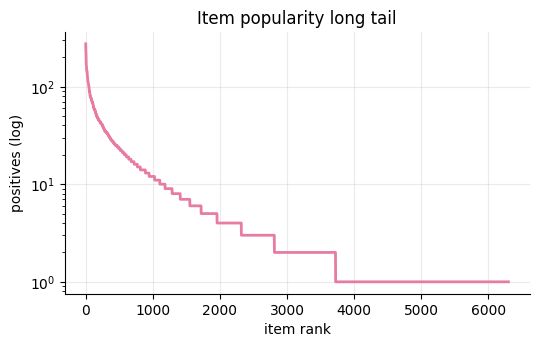

A few head items dominate -> popularity-weighted negatives make a HARD eval slice.


In [7]:
item_pop = pos.groupby('movieId').size().sort_values(ascending=False).values
fig, ax = plt.subplots(figsize=(6,3.4))
ax.plot(np.arange(len(item_pop)), item_pop, color=PALETTE[4], lw=2)
ax.set_yscale('log'); ax.set_xlabel('item rank'); ax.set_ylabel('positives (log)')
ax.set_title('Item popularity long tail'); plt.show()
print('A few head items dominate -> popularity-weighted negatives make a HARD eval slice.')

**Takeaways**
1. The matrix is ~1-2% dense — retrieval must generalize, not memorize.
2. ~half of ratings are positive; per-user counts are heavy-tailed → cold-start matters.
3. Interactions are spread over years → temporal leave-last-out is the honest split.
4. Popularity is long-tailed → popular-but-unseen items are strong hard negatives.